### Análise exploratória dos dados

In [1]:
import pandas as pd
import os
import numpy as np
pd.set_option('display.max_columns', None)

In [ ]:

## Arquivo contém todos os dados de fardinhos extraídos da base
# dados_fardinhos = pd.read_parquet('../data/bronze/dados_fardinhos.parquet')

## Somente os dados dos fardinhos que possuem amostra. Esse é o DataFrame que vou usar.
amostras_dados = pd.read_parquet('../data/silver/amostras_classificadas.parquet')

Aqui vamos garantir que todas as amostras coletadas (codigo_sai) tenham registro de dados. Podemos observar um total de 1084 codigo_sai e a mesma quantidade na base de dados.

In [3]:
amostras = []
for root, dirs, files in os.walk('../input/amostras/'):
    for file in files:
        arquivo_sem_extensao = os.path.splitext(file)[0]
        codigo_fardinho = arquivo_sem_extensao[3:]
        try:
            if int(codigo_fardinho):
                amostras.append(codigo_fardinho)
        except:
            pass

print(f'Total de fardinhos com amostras coletadas: {len(np.unique(amostras))}')
print(amostras_dados.info())

Total de fardinhos com amostras coletadas: 1084
<class 'pandas.core.frame.DataFrame'>
Index: 1084 entries, 38640 to 60876
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigosai                 1084 non-null   string 
 1   classificacao             1084 non-null   string 
 2   origem                    1084 non-null   string 
 3   numero                    1084 non-null   string 
 4   maquina_algodoeira        1084 non-null   string 
 5   fazenda_origem            1084 non-null   string 
 6   databeneficiamento        1084 non-null   string 
 7   datacolheita              1084 non-null   string 
 8   periodocolheita           1084 non-null   string 
 9   bordadura                 1084 non-null   boolean
 10  umidade                   0 non-null      float32
 11  sinistros                 1084 non-null   string 
 12  contaminantes             1084 non-null   string 
 13  localizacaolati

Podemos verificar a distribuição de amostras por classe. Temos 5 classe com um volume bem grande de amotras, enquanto as outras 5 possuem um volume com bem menos representatividade (certa de 1/3 da médias as outras).

In [4]:
qtd_por_classe = pd.DataFrame(amostras_dados.classificacao.value_counts().reset_index())
qtd_por_classe['percent'] =  round(qtd_por_classe['count'] / qtd_por_classe['count'].sum() * 100, 2)
qtd_por_classe.sort_values(by=['classificacao']).reset_index(inplace=True)
qtd_por_classe

,classificacao,count,percent
0,31.4,190,17.53
1,31.2,190,17.53
2,33.3,174,16.05
3,31.3,163,15.04
4,32.3,151,13.93
5,42.4,54,4.98
6,32.4,48,4.43
7,41.4,45,4.15
8,41.5,40,3.69
9,44.4,29,2.68


Análise das colunas do Data Frame:


- classificacao: Variável de interesse. 10 classes diferentes;
- origem: Sempre a mesma "lote". Não faz sentido usar;
- numero: É o número do lote, não faz sentido usar;
- maquina_algodoeira: Sempre a mesma "Busa". Não faz sentido usar;
- fazenda_origem: Sempre a mesma "SIRIEMA". Não faz sentido usar;
- databeneficiamento: Data e hora que o fardinho foi befeciado;
- datacolheita: Data e hora que o rolo que gerou o fardinho foi colhido (aqui é quando fez o registro)
- periodocolheita: Turno em que foi feita a colheita. (1 = matutino, 2 = vespertino, 3 = noturno)
- bordadura: Boleano indicando se é bordadura;
- umidade: Tudo nulo;
- sinistros: Está tudo vazio;
- contaminantes: Está tudo vazio;
- localizacaolatitude: Altitude do talhão em que o rolo foi colhido;
- localizacaolongitude: Posição do talhão em que o rolo foi colhido;
- localizacaoaltitude: Posição do talhão em que o rolo foi colhido;
- talhao: Número do talhão. Não faz muito sentido;
- idexterno: Código no sistema de ERP;
- areaha: Tamanho do talhão em hectares;
- dataplantio: Data em que o talhão foi plantado;
- nome_variedade: Nome da variedade da semente;
- descricao_variedade: Descrição da variedade da semente;
- nome_grupovariedade: Nome do grupo de variedade da semente;
- descricao_grupovariedade: Descrição do grupo de variedade da semente;
- rn: RowNumber, coluna auxiliar para a query. Não faz sentido manter;

In [5]:
amostras_dados['databeneficiamento'] = pd.to_datetime(amostras_dados['databeneficiamento'])
amostras_dados['datacolheita'] = pd.to_datetime(amostras_dados['datacolheita'])
amostras_dados['dataplantio'] = pd.to_datetime(amostras_dados['dataplantio'])
amostras_dados['dataplantio'] = amostras_dados['dataplantio'].dt.tz_localize('Etc/GMT+4')



amostras_dados.describe(include='all')

,codigosai,classificacao,origem,numero,maquina_algodoeira,fazenda_origem,databeneficiamento,datacolheita,periodocolheita,bordadura,umidade,sinistros,contaminantes,localizacaolatitude,localizacaolongitude,localizacaoaltitude,talhao,idexterno,areaha,dataplantio,nome_variedade,descricao_variedade,nome_grupovariedade,descricao_grupovariedade,rn
count,1084,1084,1084,1084,1084,1084,1084,1084,1084,1084,0.0,1084,1084,995.000000,995.000000,995.000000,1084,1084,1084.000000,1084,1084,1084,1084,1084,1084.0
unique,1084,10,1,34,1,1,NaN,NaN,3,2,NaN,1,1,NaN,NaN,NaN,8,8,NaN,NaN,3,3,2,2,<NA>
top,00078986195518362372,31.4,lote,62,Busa,SIRIEMA,NaN,NaN,3,False,NaN,[],[],NaN,NaN,NaN,004,2613303843408950835,NaN,NaN,TMG 22 GLTP,SEMENTE ALGODAO TMG 22 GLTP,GMO,GMO,<NA>
freq,1,190,1084,110,1084,1084,NaN,NaN,494,990,NaN,1084,1084,NaN,NaN,NaN,284,284,NaN,NaN,471,471,720,720,<NA>
mean,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-11 14:35:46.254612480-04:00,2024-08-21 23:04:59.225092096-04:00,NaN,NaN,NaN,NaN,NaN,-13.400061,-58.887962,557.320374,NaN,NaN,155.195999,2024-01-21 05:49:22.361623552-04:00,NaN,NaN,NaN,NaN,1.0
min,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-02 23:17:51-04:00,2024-08-10 06:07:00-04:00,NaN,NaN,NaN,NaN,NaN,-13.592110,-58.975388,511.399994,NaN,NaN,57.119999,2024-01-08 00:00:00-04:00,NaN,NaN,NaN,NaN,1.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-09 03:03:22.750000128-04:00,2024-08-17 07:02:00-04:00,NaN,NaN,NaN,NaN,NaN,-13.399012,-58.907913,545.299988,NaN,NaN,153.500000,2024-01-16 00:00:00-04:00,NaN,NaN,NaN,NaN,1.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-11 09:13:51.500000-04:00,2024-08-21 13:03:30-04:00,NaN,NaN,NaN,NaN,NaN,-13.361653,-58.902531,560.700012,NaN,NaN,177.000000,2024-01-24 00:00:00-04:00,NaN,NaN,NaN,NaN,1.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-15 13:30:55.249999872-04:00,2024-08-28 07:08:45-04:00,NaN,NaN,NaN,NaN,NaN,-13.352788,-58.896393,568.750000,NaN,NaN,178.000000,2024-01-26 00:00:00-04:00,NaN,NaN,NaN,NaN,1.0
max,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-16 19:43:59-04:00,2024-08-31 09:32:00-04:00,NaN,NaN,NaN,NaN,NaN,-13.346815,-58.757454,634.400024,NaN,NaN,242.699997,2024-01-29 00:00:00-04:00,NaN,NaN,NaN,NaN,1.0


#### Processamento dos dados

In [6]:
## Remover as colunas que não são úteis
variaveis_para_remover = [
    'origem',
    'numero',
    'maquina_algodoeira',
    'fazenda_origem',
    'umidade',
    'sinistros',
    'contaminantes',
    'localizacaolatitude',
    'localizacaolongitude',
    'talhao',
    'idexterno',
    'areaha',
    'descricao_variedade',
    'descricao_grupovariedade',
    'rn'
]
amostras_dados.drop(columns=variaveis_para_remover, inplace=True)
amostras_dados

,codigosai,classificacao,databeneficiamento,datacolheita,periodocolheita,bordadura,localizacaoaltitude,dataplantio,nome_variedade,nome_grupovariedade
38640,00078986195518362372,31.4,2024-10-15 08:24:35-04:00,2024-08-29 08:35:00-04:00,3,False,546.900024,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO
38653,00078986195518344149,33.3,2024-10-11 23:08:12-04:00,2024-08-29 07:27:00-04:00,1,False,540.299988,2024-01-18 00:00:00-04:00,TMG 22 GLTP,GMO
38654,00078986195518361931,31.3,2024-10-15 07:25:13-04:00,2024-08-29 07:23:00-04:00,3,False,560.700012,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO
38657,00078986195518361986,31.3,2024-10-15 07:32:18-04:00,2024-08-29 07:35:00-04:00,3,False,560.299988,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO
38658,00078986195518355930,31.3,2024-10-14 10:25:10-04:00,2024-08-29 07:25:00-04:00,1,False,546.799988,2024-01-18 00:00:00-04:00,TMG 22 GLTP,GMO
...,...,...,...,...,...,...,...,...,...,...
60856,00078986195518327906,32.4,2024-10-09 06:33:36-04:00,2024-08-21 07:40:00-04:00,1,True,538.099976,2024-01-16 00:00:00-04:00,FM 978,IPRO
60860,00078986195518325957,42.4,2024-10-08 23:19:06-04:00,2024-08-21 14:19:00-04:00,2,False,545.299988,2024-01-16 00:00:00-04:00,FM 978,IPRO
60865,00078986195518325902,42.4,2024-10-08 23:09:30-04:00,2024-08-21 13:16:00-04:00,1,False,570.900024,2024-01-16 00:00:00-04:00,FM 978,IPRO
60867,00078986195518325643,42.4,2024-10-08 22:22:15-04:00,2024-08-21 13:19:00-04:00,1,False,563.099976,2024-01-16 00:00:00-04:00,FM 978,IPRO


In [7]:
## Criar novas features:

amostras_dados['diasatebeneficiamento'] = (amostras_dados['databeneficiamento'] - amostras_dados['datacolheita']).dt.total_seconds() / 3600 / 24
amostras_dados['diasplantioatecolheita'] = (amostras_dados['datacolheita'] - amostras_dados['dataplantio']).dt.days

dummies_periodocolheita = pd.get_dummies(amostras_dados['periodocolheita'], prefix='periodocolheita')
dummies_variedade = pd.get_dummies(amostras_dados['nome_variedade'], prefix='variedade')
dummies_grupovariedade = pd.get_dummies(amostras_dados['nome_grupovariedade'], prefix='grupovariedade')

amostras_dados = pd.concat([amostras_dados, dummies_periodocolheita, dummies_variedade, dummies_grupovariedade], axis=1)

# amostras_dados.drop(columns=['databeneficiamento', 'datacolheita', 'periodocolheita', 'dataplantio', 'nome_variedade', 'nome_grupovariedade'], inplace=True)

In [8]:
amostras_dados

,codigosai,classificacao,databeneficiamento,datacolheita,periodocolheita,bordadura,localizacaoaltitude,dataplantio,nome_variedade,nome_grupovariedade,diasatebeneficiamento,diasplantioatecolheita,periodocolheita_1,periodocolheita_2,periodocolheita_3,variedade_FM 911GLTP,variedade_FM 978,variedade_TMG 22 GLTP,grupovariedade_GMO,grupovariedade_IPRO
38640,00078986195518362372,31.4,2024-10-15 08:24:35-04:00,2024-08-29 08:35:00-04:00,3,False,546.900024,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO,46.992766,218,False,False,True,False,False,True,True,False
38653,00078986195518344149,33.3,2024-10-11 23:08:12-04:00,2024-08-29 07:27:00-04:00,1,False,540.299988,2024-01-18 00:00:00-04:00,TMG 22 GLTP,GMO,43.653611,224,True,False,False,False,False,True,True,False
38654,00078986195518361931,31.3,2024-10-15 07:25:13-04:00,2024-08-29 07:23:00-04:00,3,False,560.700012,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO,47.001539,218,False,False,True,False,False,True,True,False
38657,00078986195518361986,31.3,2024-10-15 07:32:18-04:00,2024-08-29 07:35:00-04:00,3,False,560.299988,2024-01-24 00:00:00-04:00,TMG 22 GLTP,GMO,46.998125,218,False,False,True,False,False,True,True,False
38658,00078986195518355930,31.3,2024-10-14 10:25:10-04:00,2024-08-29 07:25:00-04:00,1,False,546.799988,2024-01-18 00:00:00-04:00,TMG 22 GLTP,GMO,46.125116,224,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60856,00078986195518327906,32.4,2024-10-09 06:33:36-04:00,2024-08-21 07:40:00-04:00,1,True,538.099976,2024-01-16 00:00:00-04:00,FM 978,IPRO,48.953889,218,True,False,False,False,True,False,False,True
60860,00078986195518325957,42.4,2024-10-08 23:19:06-04:00,2024-08-21 14:19:00-04:00,2,False,545.299988,2024-01-16 00:00:00-04:00,FM 978,IPRO,48.375069,218,False,True,False,False,True,False,False,True
60865,00078986195518325902,42.4,2024-10-08 23:09:30-04:00,2024-08-21 13:16:00-04:00,1,False,570.900024,2024-01-16 00:00:00-04:00,FM 978,IPRO,48.412153,218,True,False,False,False,True,False,False,True
60867,00078986195518325643,42.4,2024-10-08 22:22:15-04:00,2024-08-21 13:19:00-04:00,1,False,563.099976,2024-01-16 00:00:00-04:00,FM 978,IPRO,48.377257,218,True,False,False,False,True,False,False,True


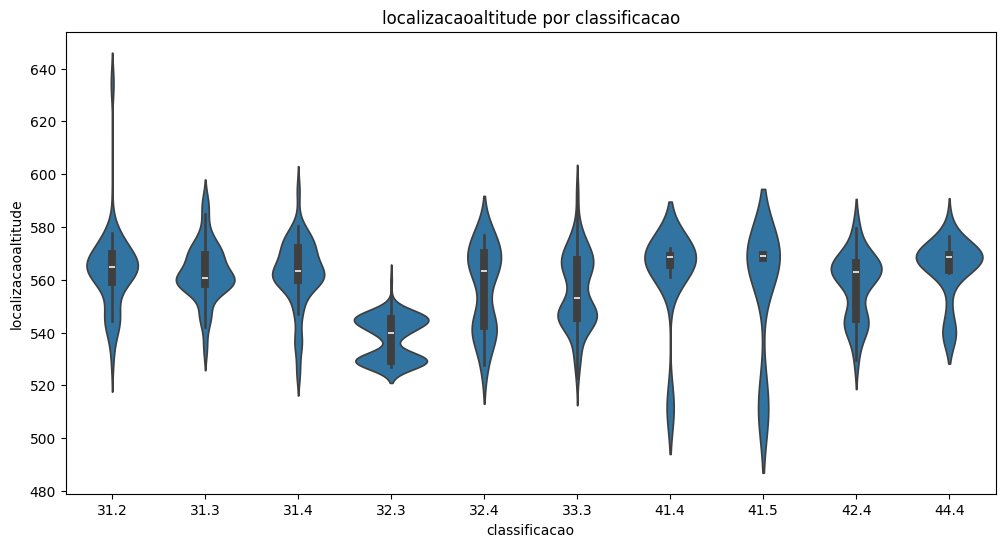

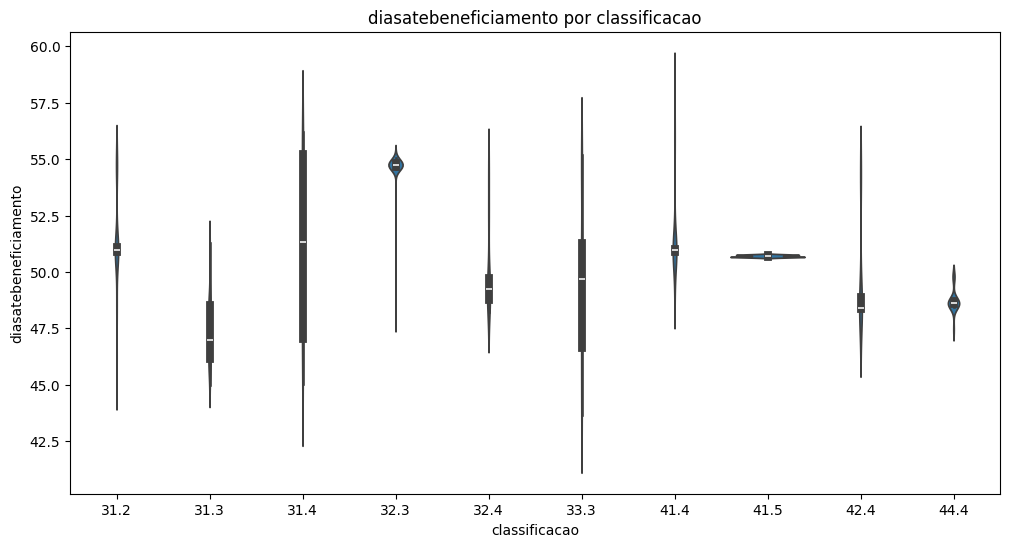

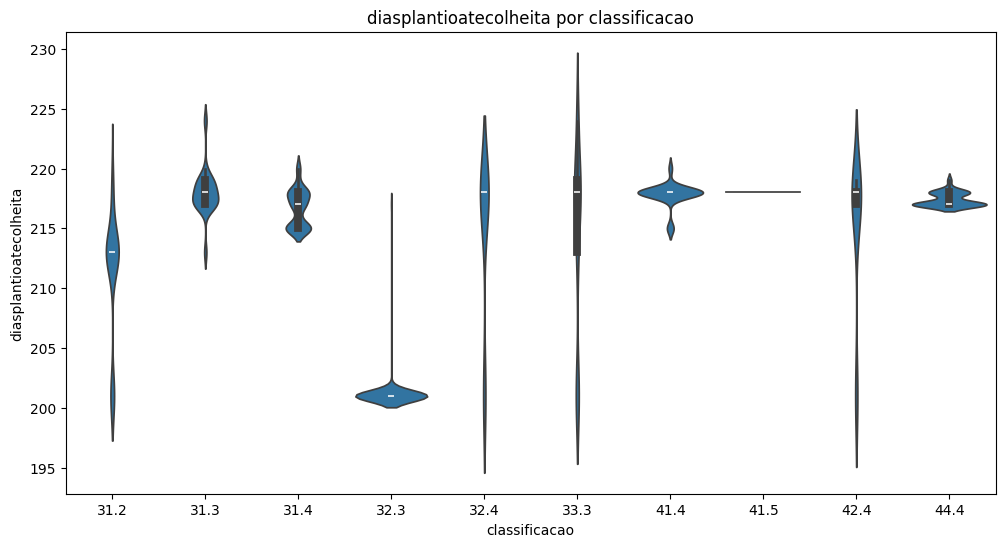

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_grafico_violino(y):
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='classificacao', y=y, data=amostras_dados, order=np.sort(amostras_dados.classificacao.unique()))
    plt.title(f'{y} por classificacao')
    plt.show()

vars = ['localizacaoaltitude', 'diasatebeneficiamento', 'diasplantioatecolheita']
for var in vars:
    plotar_grafico_violino(var)

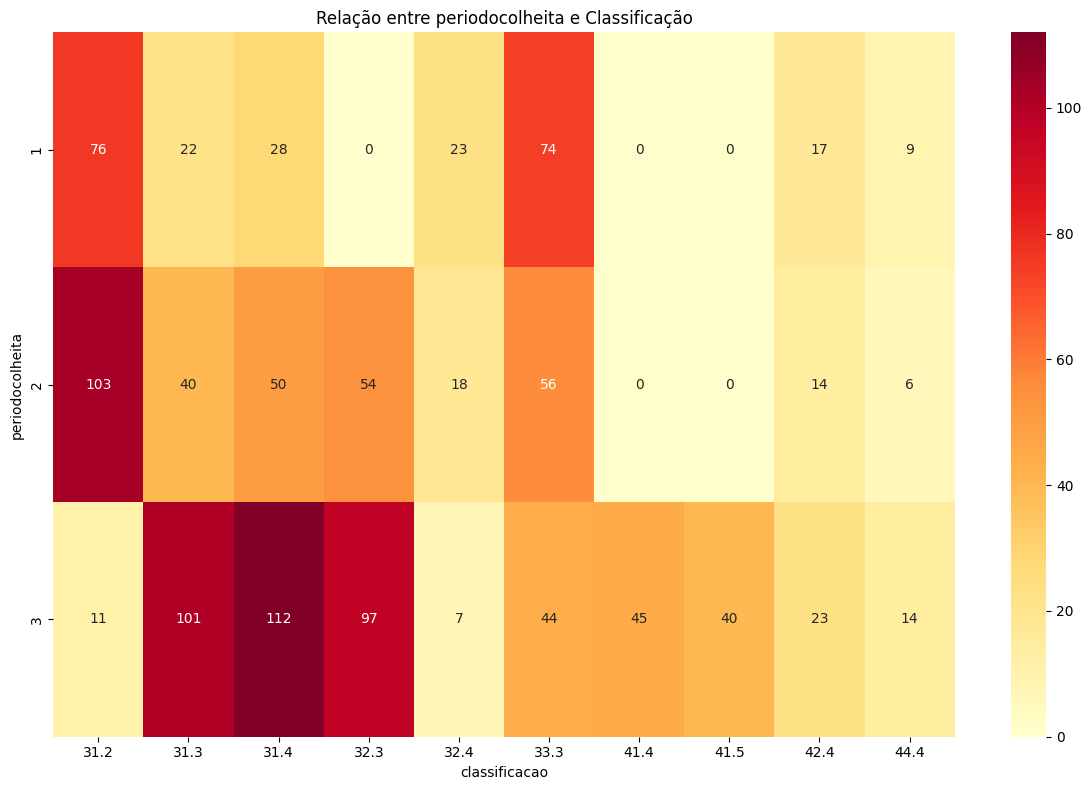

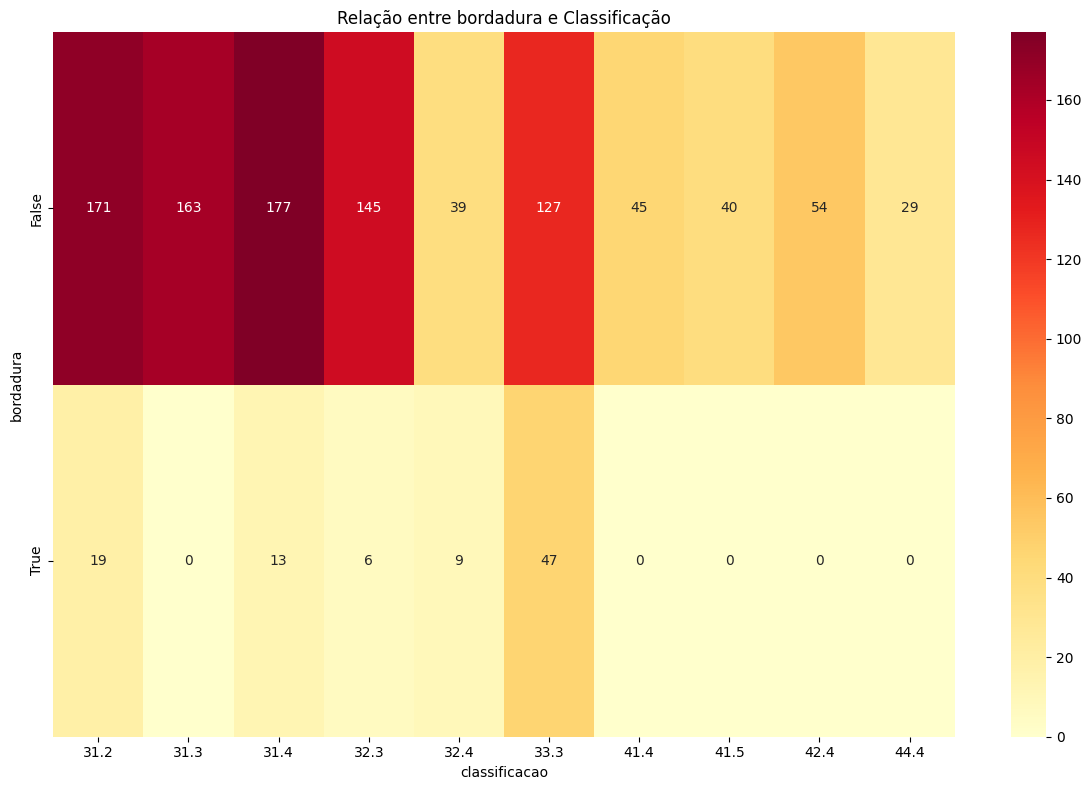

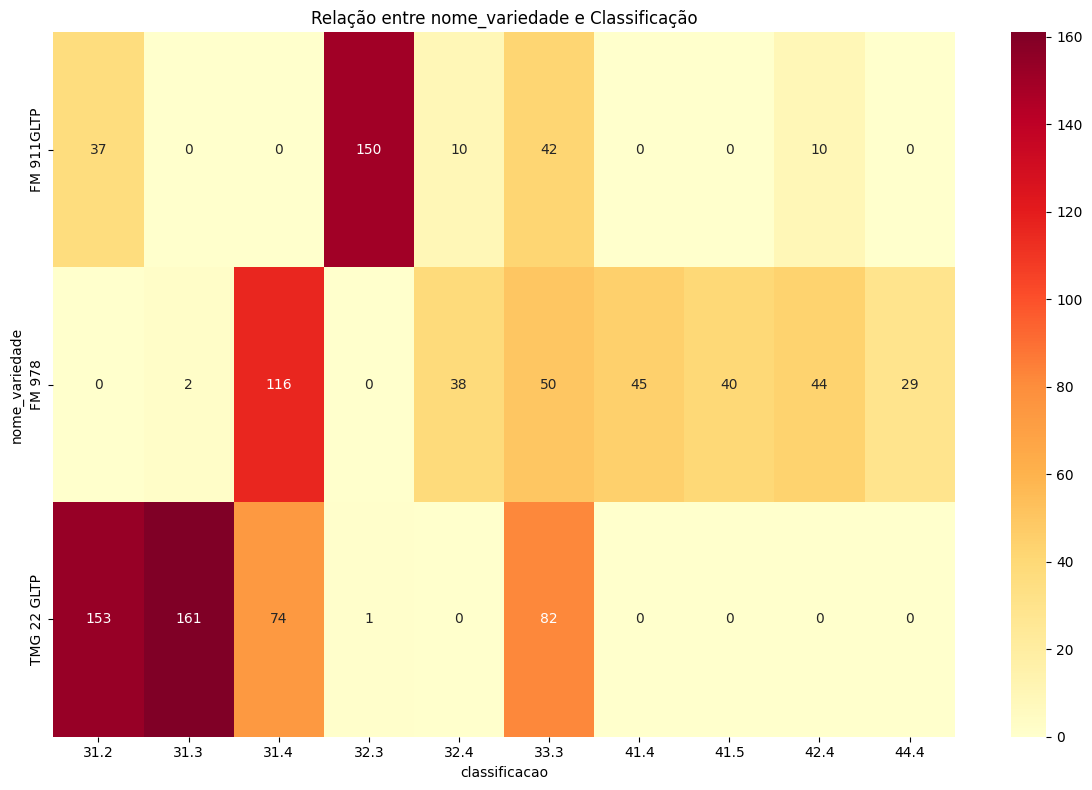

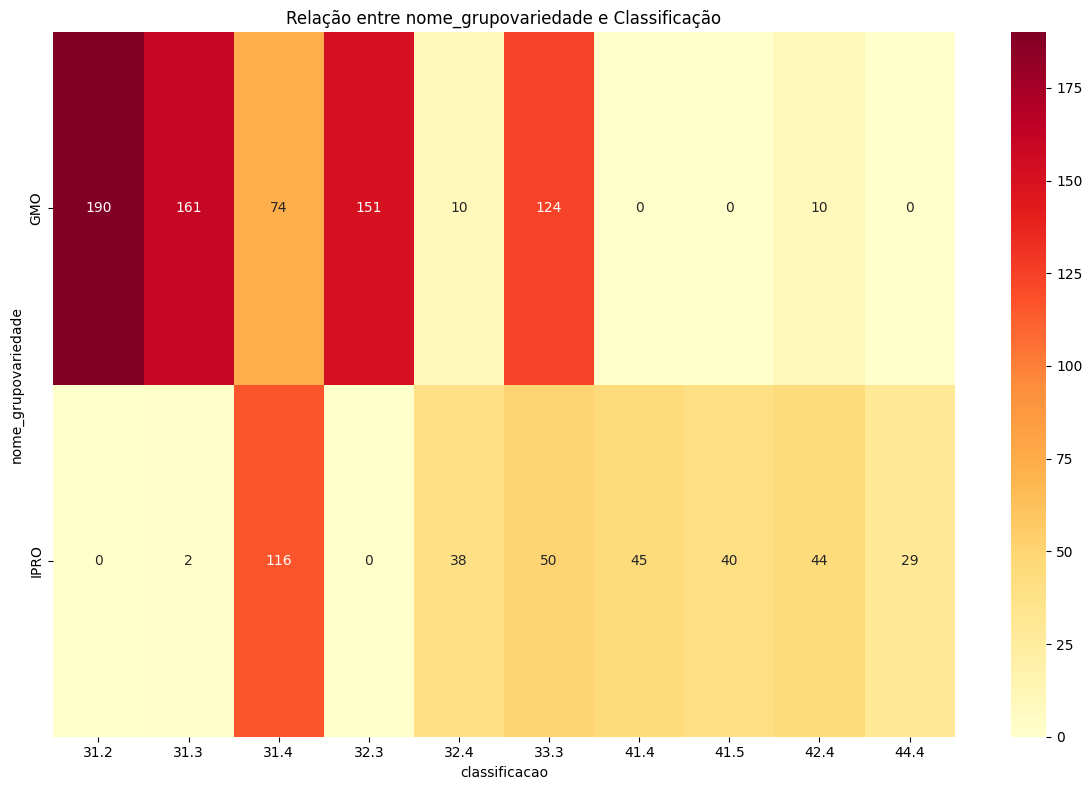

In [27]:

def plotar_grafico_heatmap(var):
    contingency_table = pd.crosstab(amostras_dados[var], amostras_dados['classificacao'])
    # Criar o heatmap: 254987
    plt.figure(figsize=(12, 8))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
    plt.title(f'Relação entre {var} e Classificação')
    plt.tight_layout()
    plt.show()

vars = ['periodocolheita', 'bordadura', 'nome_variedade', 'nome_grupovariedade']
for var in vars:
    plotar_grafico_heatmap(var)

Testes estatísticos

- Qui-quadrado
- Teste Exato de Fisher
- Correlação de Spearman
- Kruskal-Wallis

In [53]:
from scipy.stats import chi2_contingency

def fazer_teste_qui_quadrado(dados, variaveis):
    resultados = []
    for variavel in variaveis:
        tabela_contingencia = pd.crosstab(dados[variavel], dados['classificacao'])
        qui2, valor_p, gdl, _ = chi2_contingency(tabela_contingencia)
        n = tabela_contingencia.sum().sum()
        v_cramer = np.sqrt(qui2 / (n * min(tabela_contingencia.shape) - 1))
        resultados.append({
                'variavel': variavel,
                'estatistica_qui_quadrado': qui2,
                'valor_p': valor_p,
                'graus_de_liberdade': gdl,
                'v_cramer': v_cramer
            })
    return pd.DataFrame(resultados)

vars = ['periodocolheita', 'bordadura', 'nome_variedade', 'nome_grupovariedade']
fazer_teste_qui_quadrado(amostras_dados, vars)

,variavel,estatistica_qui_quadrado,valor_p,graus_de_liberdade,v_cramer
0,periodocolheita,375.660366,1.070994e-68,18,0.339930
1,bordadura,116.918389,5.703784e-21,9,0.232280
2,nome_variedade,1251.771777,8.979058e-255,18,0.620518
3,nome_grupovariedade,640.792056,3.654172e-132,9,0.543787


In [54]:
from scipy.stats import fisher_exact

def fazer_teste_exato_fisher(dados, variaveis):
    resultados = []
    for variavel in variaveis:
        tabela_contingencia = pd.crosstab(dados[variavel], dados['classificacao'])
        odds_ratio, valor_p = fisher_exact(tabela_contingencia)
        resultados.append({
            'variavel': variavel,
            'odds_ratio': odds_ratio,
            'p_valor': valor_p
        })
    return pd.DataFrame(resultados)

vars = ['periodocolheita', 'bordadura', 'nome_variedade', 'nome_grupovariedade']
fazer_teste_exato_fisher(amostras_dados, vars)

,variavel,odds_ratio,p_valor
0,periodocolheita,1.475286e-114,0.0001
1,bordadura,2.067110e-30,0.0001
2,nome_variedade,3.066215e-302,0.0001
3,nome_grupovariedade,3.446863e-177,0.0001


Testes de associação
	1.	Teste exato de Fisher: Adequado para tabelas de contingência com células de baixa contagem ou zeradas.
	2.	Teste da razão de verossimilhança: Uma alternativa ao qui-quadrado que pode ser mais robusto para amostras pequenas.
	3.	Teste de Monte Carlo: Útil quando as premissas do qui-quadrado não são atendidas devido a células com baixa contagem.
	4.	Teste Binomial Exato Condicional (CBET): Recomendado para tabelas com contagens zero.
	5.	Teste mid-P de Lancaster: Outra opção para lidar com células zeradas.
Medidas de força de associação
	1.	V de Cramer: Uma versão normalizada do qui-quadrado, variando de 0 a 1.
	2.	Tau de Goodman e Kruskal: Uma medida assimétrica que pode ser útil para explorar relações direcionais entre variáveis.
	3.	Coeficiente de contingência C: Semelhante ao V de Cramer, mas com um limite superior que varia conforme o tamanho da tabela.
	4.	Odds ratio: Aplicável principalmente para tabelas 2x2, mas pode ser estendido para tabelas maiores comparando categorias específicas.
	5.	Lambda de Goodman-Kruskal: Baseada na redução proporcional do erro de previsão.
Considerações importantes
	•	Para tabelas com células zeradas, métodos como CBET, teste mid-P de Lancaster e máxima verossimilhança penalizada são recomendados.
	•	A escolha do método deve considerar o tamanho da amostra, a distribuição dos dados e os objetivos específicos da análise.
	•	Visualizações gráficas, como gráficos de mosaico ou mapas de calor, podem complementar a análise estatística.
	•	Para tabelas grandes com muitas categorias, pode ser útil considerar a combinação de categorias ou o uso de métodos de análise log-linear.
Ao aplicar esses métodos, é importante interpretar os resultados no contexto do problema e considerar múltiplas abordagens para obter uma compreensão mais robusta da associação entre as variáveis.

In [56]:
from scipy.stats import spearmanr, kruskal

unique_categories = np.sort(amostras_dados['classificacao'].unique())
mapping = {category: i for i, category in enumerate(unique_categories)}
amostras_dados['classificacao_ordinal'] = amostras_dados['classificacao'].map(mapping)


def calcular_correlacao_kruskal_wallis(dados, variaveis):

    resultados = []
    for variavel in variaveis:
        # Correlação Spearman:
        corr, spearman_valor_p = spearmanr(
            dados[variavel], 
            amostras_dados['classificacao_ordinal'], 
            nan_policy='omit'
        )

        # Kruskal-wallis:
        grupos = [dados[dados['classificacao_ordinal'] == category][variavel] for category in dados['classificacao_ordinal'].unique()]
        kruskal_estatistica, kruskal_valor_p = kruskal(*grupos, nan_policy='omit')

        resultados.append({
            'variavel': variavel,
            'corr': corr,
            'spearman_valor_p': spearman_valor_p,
            'kruskal_estatistica': kruskal_estatistica,
            'kruskal_valor_p': kruskal_valor_p
        })
    return pd.DataFrame(resultados)

vars = ['localizacaoaltitude', 'diasplantioatecolheita', 'diasatebeneficiamento']
calcular_correlacao_kruskal_wallis(amostras_dados, vars)

,variavel,corr,spearman_valor_p,kruskal_estatistica,kruskal_valor_p
0,localizacaoaltitude,-0.110687,4.690479e-04,280.829642,3.018574e-55
1,diasplantioatecolheita,0.185854,7.011521e-10,538.373483,3.458515e-110
2,diasatebeneficiamento,0.011273,7.108359e-01,428.963494,8.976236e-87


In [40]:
amostras_dados.to_csv('teste.csv')